# Business Card OCR Pipeline

Notebook ini berisi eksperimen end-to-end untuk mengekstrak informasi terstruktur dari foto kartu nama.  
Pipeline terdiri dari tiga tahap utama:

1. **Pre-processing** : Deteksi kartu, koreksi perspektif, dan peningkatan kualitas gambar
2. **Inference (OCR)** : Ekstraksi teks menggunakan PaddleOCR
3. **Parsing** : Ekstraksi entitas terstruktur (nama, perusahaan, email, telepon) menggunakan SpaCy dan Regex

---

## Hipotesis

Kombinasi antara:
- Deteksi kontur berbasis HSV (bukan Canny edge detection murni)
- Normalisasi background adaptif sebelum thresholding
- Hybrid parsing (Regex untuk pola deterministik + SpaCy NER untuk entitas semantik)

diharapkan menghasilkan ekstraksi yang lebih robust terhadap variasi pencahayaan dan desain kartu nama dibandingkan pendekatan pipeline tunggal.

---

# Bagian 1 : Pre-processing

Tahap ini bertanggung jawab untuk:
1. Mendeteksi region kartu nama dalam foto
2. Melakukan koreksi perspektif (*perspective warp*) agar kartu tampak datar
3. Meningkatkan kualitas gambar untuk memaksimalkan akurasi OCR

Seluruh fungsi dirancang modular sehingga setiap komponen dapat diuji dan diganti secara independen.

## 1.1 Utilitas & Import

In [1]:
import cv2
import numpy as np
import imutils
import matplotlib.pyplot as plt
from typing import Dict, Optional, Tuple

In [2]:
def display_img(img: np.ndarray, title: str = "Image") -> None:
    """Menampilkan gambar OpenCV (BGR) menggunakan Matplotlib."""
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

## 1.2 Peningkatan Kecerahan Adaptif

Fungsi ini mendeteksi apakah gambar masuk dalam kategori *underexposed* berdasarkan rata-rata channel Value (V) dalam ruang warna HSV.  
Jika gambar dianggap gelap (mean Value < 100), CLAHE (*Contrast Limited Adaptive Histogram Equalization*) diterapkan pada channel V untuk meningkatkan kecerahan secara lokal tanpa overexposure.

**Alasan menggunakan HSV dan bukan langsung histogram equalization pada BGR:**  
Manipulasi pada channel Value HSV mempertahankan informasi warna (hue & saturation), sehingga tidak menghasilkan artefak warna yang mengganggu deteksi kontur di tahap berikutnya.

In [3]:
def enhance_brightness(image: np.ndarray, dark_threshold: int = 100) -> np.ndarray:
    """
    Meningkatkan kecerahan gambar secara adaptif jika terdeteksi underexposed.

    Args:
        image: Gambar input dalam format BGR.
        dark_threshold: Batas rata-rata channel Value HSV untuk dikategorikan gelap.

    Returns:
        Gambar dengan kecerahan yang telah dikoreksi (jika diperlukan).
    """
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    mean_v = np.mean(hsv[:, :, 2])

    if mean_v < dark_threshold:
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        hsv[:, :, 2] = clahe.apply(hsv[:, :, 2])
        image = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

    return image

## 1.3 Deteksi Kartu Nama

Fungsi ini mendeteksi region kartu nama dalam foto menggunakan pendekatan segmentasi berbasis HSV.

**Strategi deteksi:**
- **Channel Saturation (S):** Kartu nama umumnya berwarna netral (putih/abu). Area dengan saturasi rendah diinversi untuk menjadi *foreground*.
- **Channel Value (V):** Area terang dijadikan *foreground*.
- **Intersection (AND):** Menggabungkan kedua mask lalu mencari area yang sekaligus *rendah saturasi* dan *terang*, yang merupakan karakteristik khas kartu nama putih.

**Fallback:** Jika tidak ditemukan kontur dengan 4 sudut (quadrilateral), fungsi menggunakan bounding box minimum sebagai pendekatan.

**Nilai yang dikembalikan:**
- `orig`: Gambar asli (setelah brightness enhancement)
- `debug_img`: Gambar dengan kontur terdeteksi yang divisualisasikan
- `is_detected`: Boolean status keberhasilan deteksi
- `angle`: Estimasi sudut rotasi kartu
- `corners`: Koordinat 4 sudut kartu dalam skala gambar asli

In [4]:
def detect_business_card(
    image_path: str,
    min_area_ratio: float = 0.05
) -> Tuple[Optional[np.ndarray], Optional[np.ndarray], bool, float, Optional[np.ndarray]]:
    """
    Mendeteksi region kartu nama dalam sebuah foto menggunakan segmentasi HSV.

    Args:
        image_path: Path ke file gambar.
        min_area_ratio: Rasio minimum luas kontur terhadap luas gambar agar dianggap valid.

    Returns:
        Tuple berisi (original_image, debug_image, is_detected, angle, corners).
    """
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Gambar tidak ditemukan: {image_path}")

    image = enhance_brightness(image)
    orig = image.copy()

    ratio = image.shape[0] / 500.0
    image = imutils.resize(image, height=500)

    # --- Segmentasi HSV ---
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    saturation = hsv[:, :, 1]
    value = hsv[:, :, 2]

    # Kartu putih: saturasi rendah (diinversi) DAN terang
    _, binary_s = cv2.threshold(saturation, 45, 255, cv2.THRESH_BINARY_INV)
    _, binary_v = cv2.threshold(value, 150, 255, cv2.THRESH_BINARY)
    binary = cv2.bitwise_and(binary_s, binary_v)

    # --- Morfologi untuk menghilangkan noise ---
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)

    # --- Pencarian Kontur ---
    cnts = cv2.findContours(binary.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)

    min_area = (image.shape[0] * image.shape[1]) * min_area_ratio
    cnts = [c for c in cnts if cv2.contourArea(c) > min_area]
    cnts = sorted(cnts, key=cv2.contourArea, reverse=True)[:5]

    screenCnt = None
    angle = 0.0

    for c in cnts:
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.02 * peri, True)

        if len(approx) == 4:
            screenCnt = approx
            rect = cv2.minAreaRect(c)
            angle = rect[-1]
            break

    # --- Fallback: Bounding Box Minimum ---
    if screenCnt is None and len(cnts) > 0:
        print("[WARNING] Kontur 4 sudut tidak ditemukan. Menggunakan minimum bounding box sebagai fallback.")
        c = cnts[0]
        rect = cv2.minAreaRect(c)
        box = cv2.boxPoints(rect)
        screenCnt = np.int0(box)
        angle = rect[-1]

    # --- Normalisasi Sudut OpenCV ---
    if angle > 45:
        angle = 90 - angle
    elif angle < -45:
        angle = 90 + angle
    else:
        angle = -angle

    if screenCnt is None:
        print("[ERROR] Deteksi gagal. Parameter threshold HSV mungkin tidak sesuai dengan kondisi pencahayaan gambar.")
        return orig, binary, False, 0.0, None

    debug_img = image.copy()
    cv2.drawContours(debug_img, [screenCnt], -1, (0, 255, 0), 2)

    screenCnt_original = screenCnt.reshape(4, 2) * ratio

    return orig, debug_img, True, angle, screenCnt_original

Status  : Kartu terdeteksi
Rotasi  : 26.91 derajat


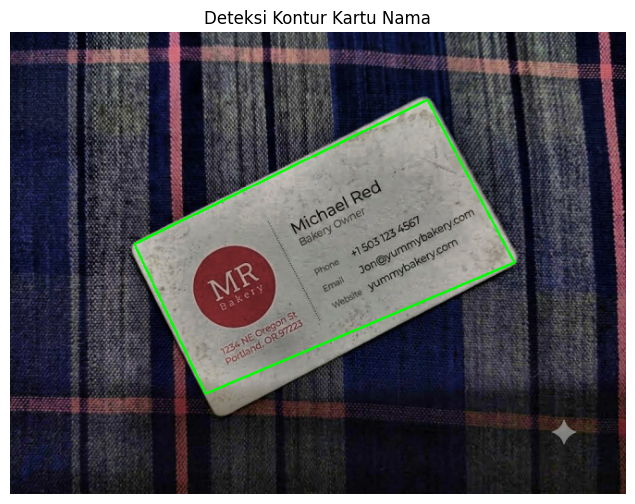

In [16]:
orig_img, debug_img, is_detected, angle, corners = detect_business_card("5.jpg")

if is_detected:
    print(f"Status  : Kartu terdeteksi")
    print(f"Rotasi  : {angle:.2f} derajat")
    display_img(debug_img, "Deteksi Kontur Kartu Nama")
else:
    print("[INFO] Deteksi gagal. Menampilkan edge map untuk diagnosis.")
    img_gray = cv2.cvtColor(imutils.resize(orig_img, height=500), cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    blurred = cv2.GaussianBlur(clahe.apply(img_gray), (5, 5), 0)
    edged = cv2.dilate(
        cv2.Canny(blurred, 30, 150),
        np.ones((3, 3), np.uint8),
        iterations=1
    )
    display_img(edged, "Debug: Edge Detection Map")

## 1.4 Koreksi Perspektif (*Perspective Warp*)

Setelah 4 sudut kartu ditemukan, perspektif gambar dikoreksi sehingga kartu tampak diambil dari sudut tegak lurus.  
Proses ini menggunakan *four-point perspective transform*:

1. **`order_points`**: Mengurutkan 4 titik sudut secara konsisten — top-left, top-right, bottom-right, bottom-left — menggunakan properti geometri jumlah dan selisih koordinat.
2. **`four_point_transform`**: Menghitung dan mengaplikasikan matriks transformasi perspektif menggunakan `cv2.getPerspectiveTransform`.

In [17]:
def order_points(pts: np.ndarray) -> np.ndarray:
    """
    Mengurutkan 4 titik koordinat secara konsisten:
    top-left, top-right, bottom-right, bottom-left.

    Args:
        pts: Array (4, 2) koordinat titik.

    Returns:
        Array (4, 2) dalam urutan yang konsisten.
    """
    rect = np.zeros((4, 2), dtype="float32")

    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]   # top-left: jumlah terkecil
    rect[2] = pts[np.argmax(s)]   # bottom-right: jumlah terbesar

    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]  # top-right: selisih terkecil
    rect[3] = pts[np.argmax(diff)]  # bottom-left: selisih terbesar

    return rect


def four_point_transform(image: np.ndarray, pts: np.ndarray) -> np.ndarray:
    """
    Mengaplikasikan transformasi perspektif pada gambar berdasarkan 4 titik sudut.

    Args:
        image: Gambar input dalam format BGR.
        pts: Array (4, 2) koordinat sudut kartu dalam gambar asli.

    Returns:
        Gambar hasil warp perspektif dalam orientasi frontal.
    """
    rect = order_points(pts)
    (tl, tr, br, bl) = rect

    widthA = np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))
    widthB = np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))
    maxWidth = max(int(widthA), int(widthB))

    heightA = np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))
    heightB = np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))
    maxHeight = max(int(heightA), int(heightB))

    dst = np.array([
        [0, 0],
        [maxWidth - 1, 0],
        [maxWidth - 1, maxHeight - 1],
        [0, maxHeight - 1]
    ], dtype="float32")

    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(image, M, (maxWidth, maxHeight))

    return warped

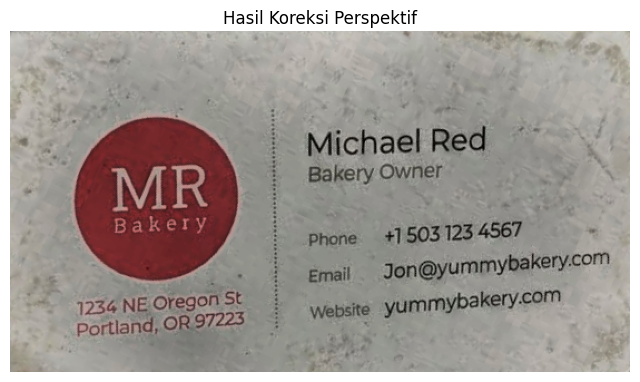

In [18]:
if is_detected:
    warped_card = four_point_transform(orig_img, corners)
    
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(warped_card, cv2.COLOR_BGR2RGB))
    plt.title("Hasil Koreksi Perspektif")
    plt.axis("off")
    plt.show()
else:
    raise RuntimeError("Kartu tidak terdeteksi. Jalankan kembali cell deteksi sebelum melanjutkan.")

## 1.5 Peningkatan Kualitas untuk OCR

Tahap ini menghasilkan beberapa varian preprocessing untuk diuji secara komparatif.  
Pendekatan multi-varian digunakan karena tidak ada satu metode thresholding yang optimal untuk semua kondisi kartu nama.

**Pipeline enhancement:**

| Langkah | Metode | Tujuan |
|---|---|---|
| Upscale 2x | Bicubic interpolation | Memperbesar teks kecil agar lebih mudah dibaca OCR |
| Denoising | `fastNlMeansDenoising` | Mengurangi noise tekstur tanpa merusak tepi karakter |
| Background normalization | Gaussian blur + divide | Menetralisir efek gradien pencahayaan dan bayangan |
| CLAHE | clip=1.5, tile=(8,8) | Meningkatkan kontras lokal secara adaptif |
| Sharpening | Unsharp masking | Mempertajam tepi karakter |
| Otsu threshold | Binarisasi global | Optimal untuk background seragam |
| Adaptive threshold | Gaussian weighted | Optimal untuk background tidak seragam |

**Output:** Dictionary berisi semua varian gambar untuk dievaluasi secara visual.

In [19]:
def enhance_for_ocr_variants(warped_img: np.ndarray) -> Dict[str, np.ndarray]:
    """
    Menghasilkan beberapa varian preprocessing gambar untuk eksperimen OCR.

    Args:
        warped_img: Gambar kartu hasil koreksi perspektif (BGR atau grayscale).

    Returns:
        Dictionary berisi varian gambar yang telah diproses.
    """
    if warped_img is None or warped_img.size == 0:
        raise ValueError("Input image kosong atau None.")

    gray = warped_img if warped_img.ndim == 2 else cv2.cvtColor(warped_img, cv2.COLOR_BGR2GRAY)

    # Upscale untuk meningkatkan resolusi teks
    gray = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

    # Denoising
    denoised = cv2.fastNlMeansDenoising(gray, None, h=12, templateWindowSize=7, searchWindowSize=21)

    # Background normalization: menetralisir gradien pencahayaan
    background = cv2.GaussianBlur(denoised, (0, 0), sigmaX=25, sigmaY=25)
    normalized = cv2.divide(denoised, background, scale=255)

    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
    clahe_img = clahe.apply(normalized)

    # Unsharp masking
    blur = cv2.GaussianBlur(clahe_img, (0, 0), sigmaX=1.0)
    sharpened = cv2.addWeighted(clahe_img, 1.3, blur, -0.3, 0)

    # Otsu binarization
    _, otsu = cv2.threshold(sharpened, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Adaptive Gaussian thresholding
    adaptive = cv2.adaptiveThreshold(
        sharpened, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=41,
        C=15
    )

    # Morphological cleanup pada hasil adaptive
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    adaptive_clean = cv2.morphologyEx(adaptive, cv2.MORPH_OPEN, kernel, iterations=1)

    return {
        "gray": gray,
        "normalized": normalized,
        "clahe": clahe_img,
        "sharpened": sharpened,
        "otsu": otsu,
        "adaptive": adaptive_clean,
    }

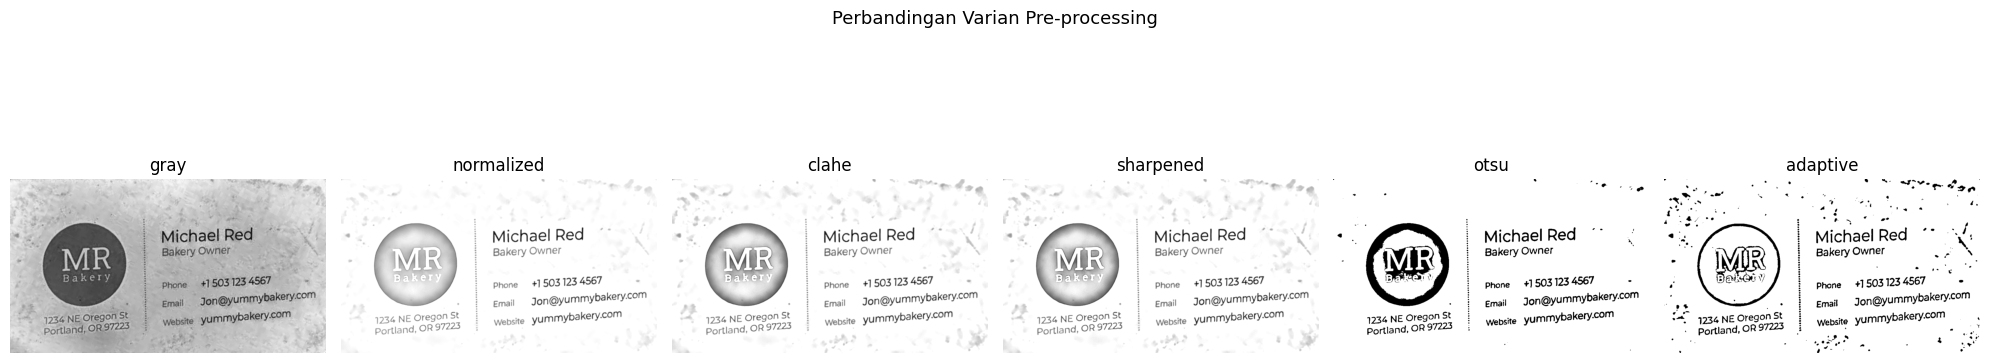

In [20]:
variants = enhance_for_ocr_variants(warped_card)

fig, axes = plt.subplots(1, len(variants), figsize=(20, 5))
fig.suptitle("Perbandingan Varian Pre-processing", fontsize=13)

for ax, (name, img) in zip(axes, variants.items()):
    ax.imshow(img, cmap="gray")
    ax.set_title(name)
    ax.axis("off")

plt.tight_layout()
plt.show()

---

# Bagian 2 : Inference (OCR)

Tahap ini mengekstrak teks dari gambar kartu yang telah diproses menggunakan **PaddleOCR**.  

PaddleOCR dipilih karena:
- Mendukung deteksi teks multi-orientasi melalui angle classifier
- Akurasi yang kompetitif untuk teks dalam bahasa Inggris
- Tidak membutuhkan konfigurasi layout yang kompleks untuk kartu nama

Varian gambar yang digunakan sebagai input dapat diubah untuk menguji pengaruh preprocessing terhadap kualitas OCR.

## 2.1 Konfigurasi Environment

Flag berikut menonaktifkan MKL-DNN dan PIR API pada PaddlePaddle, yang diketahui dapat menyebabkan konflik pada environment tertentu.

In [21]:
import os

os.environ["PADDLE_PDX_ENABLE_MKLDNN_BYDEFAULT"] = "0"
os.environ["FLAGS_use_mkldnn"] = "0"
os.environ["FLAGS_enable_pir_api"] = "0"

## 2.2 Inisialisasi Engine OCR

In [22]:
import logging
logging.getLogger('ppocr').setLevel(logging.ERROR)

from paddleocr import PaddleOCR

# Inisialisasi engine dengan angle classifier diaktifkan
# Parameter ini dibutuhkan untuk menangani teks yang mungkin tidak sepenuhnya horizontal
ocr_engine = PaddleOCR(use_angle_cls=True, lang='en')
print("OCR engine berhasil diinisialisasi.")

OCR engine berhasil diinisialisasi.


## 2.3 Eksekusi OCR

Input ke engine OCR menggunakan varian `otsu` sebagai baseline eksperimen.  
Varian dapat diganti dengan `adaptive`, `sharpened`, atau lainnya untuk perbandingan.

PaddleOCR membutuhkan input 3-channel (BGR), sehingga gambar grayscale dikonversi terlebih dahulu.

In [23]:
# Pilih varian preprocessing yang akan digunakan sebagai input OCR
SELECTED_VARIANT = "otsu"  # Ubah untuk eksperimen: "adaptive", "sharpened", dll.

input_img = variants[SELECTED_VARIANT]

# Konversi ke 3-channel jika masih grayscale
if len(input_img.shape) == 2:
    input_img = cv2.cvtColor(input_img, cv2.COLOR_GRAY2BGR)

print(f"Variant yang digunakan : {SELECTED_VARIANT}")
print(f"Dimensi input          : {input_img.shape}")

results = ocr_engine.ocr(input_img, cls=True)
detected_text = []

if not results or results[0] is None:
    print("[INFO] Tidak ada teks yang terdeteksi pada gambar ini.")
else:
    print("\nHasil OCR:")
    print("-" * 40)
    for line in results[0]:
        text = line[1][0]
        score = line[1][1]
        print(f"[{score:.4f}]  {text}")
        detected_text.append(text)

Variant yang digunakan : otsu
Dimensi input          : (612, 1114, 3)

Hasil OCR:
----------------------------------------
[0.9527]  Michael Red.
[0.9991]  MR
[0.9996]  Bakery Owner
[0.8901]  Bakery
[0.9984]  Phone
[0.9469]  +1 503 123 4567
[0.9997]  Jon@yummybakery.com
[0.9992]  Email
[0.9619]  1234 NE Oregon St
[0.5993]  +.++
[0.9820]  Website yummybakery.com
[0.9688]  Portland, OR 97223
[0.5388]  :  *


---

# Bagian 3 : Parsing dengan SpaCy

Tahap ini mengekstrak entitas terstruktur dari teks mentah hasil OCR menggunakan **pendekatan hybrid**:

- **Regex** untuk pola yang deterministik dan berstruktur tinggi (email, nomor telepon)
- **SpaCy NER** untuk entitas semantik yang tidak memiliki pola tetap (nama orang, nama perusahaan)

**Alasan menggunakan pendekatan hybrid dan bukan murni NER:**  
Model NER bersifat probabilistik dan dapat salah mengklasifikasikan nomor telepon atau alamat email sebagai entitas semantik.  
Sebaliknya, regex sangat rigid dan tidak dapat mengenali nama orang atau perusahaan.  
Kombinasi keduanya menghasilkan ekstraksi yang lebih akurat dan robust.

## 3.1 Inisialisasi SpaCy

In [24]:
import spacy
import re
import json

try:
    nlp = spacy.load("en_core_web_sm")
    print("SpaCy model 'en_core_web_sm' berhasil dimuat.")
except OSError:
    raise RuntimeError(
        "Model SpaCy tidak ditemukan. "
        "Jalankan: python -m spacy download en_core_web_sm"
    )

SpaCy model 'en_core_web_sm' berhasil dimuat.


## 3.2 Fungsi Parsing Hybrid

**Alur pemrosesan per baris teks:**

1. Regex email diuji terlebih dahulu, jika cocok, baris dilewati dan tidak diteruskan ke NER
2. Regex telepon diuji, mendeteksi prefix umum (`cel`, `ph`, `tel`) maupun format digit murni
3. Teks yang tersisa diteruskan ke SpaCy NER untuk identifikasi `PERSON` dan `ORG`

**Label SpaCy yang relevan:**
- `PERSON` → kandidat nama
- `ORG` → kandidat nama perusahaan

In [25]:
def parse_with_hybrid_ner(lines: list) -> dict:
    """
    Mengekstrak entitas terstruktur dari teks OCR menggunakan pendekatan hybrid:
    Regex untuk pola deterministik, SpaCy NER untuk entitas semantik.

    Args:
        lines: List baris teks hasil OCR.

    Returns:
        Dictionary berisi entitas yang diekstrak: name, company, email, phone.
    """
    data = {
        "name": None,
        "company": None,
        "email": None,
        "phone": None
    }
    phones = []

    for text in lines:
        text = text.strip()
        if not text:
            continue

        # --- Regex: Email ---
        if not data["email"]:
            email_match = re.search(
                r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}', text
            )
            if email_match:
                data["email"] = email_match.group()
                continue

        # --- Regex: Nomor Telepon ---
        phone_match = re.search(
            r'(cel|ph|tel|hp|mob)[\.\:\s]*\+?[\d\-\s]{8,}', text, re.IGNORECASE
        )
        digit_only_match = re.search(r'\+?\d{3,}[\-\s]?\d{4,}', text)

        if phone_match or (digit_only_match and len(re.sub(r'\D', '', text)) >= 8):
            clean_number = re.sub(r'^[a-zA-Z\.\:\s]+', '', text).strip()
            phones.append(clean_number)
            continue

        # --- SpaCy NER: Nama & Perusahaan ---
        doc = nlp(text)
        for ent in doc.ents:
            if not data["company"] and ent.label_ == "ORG" and len(ent.text) > 3:
                data["company"] = ent.text
            elif not data["name"] and ent.label_ == "PERSON":
                data["name"] = ent.text

    if phones:
        data["phone"] = " / ".join(phones)

    return data

## 3.3 Eksekusi & Evaluasi Hasil

In [26]:
parsed_result = parse_with_hybrid_ner(detected_text)

print("Hasil Parsing Entitas:")
print("-" * 40)
print(json.dumps(parsed_result, indent=4))

Hasil Parsing Entitas:
----------------------------------------
{
    "name": "Michael Red",
    "company": "Bakery",
    "email": "Jon@yummybakery.com",
    "phone": "+1 503 123 4567"
}
